## Iowa County Enumeration

Roots are fixed in corners

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path
ROOT_DIR = Path.cwd().parents[1]
sys.path.insert(0, str(ROOT_DIR))

from src.read import read_graph_from_json
from src.utils import get_roots
from src.experiment import run_enumeration_experiment
from src.draw import visualize_roots
import os
import matplotlib.pyplot as plt

os.makedirs("../../results", exist_ok=True)

In [3]:
G_ia = read_graph_from_json("../../data/IA_county.json", state="IA")

print(
    f"Iowa county graph: {G_ia.number_of_nodes()} nodes, {G_ia.number_of_edges()} edges"
)

Iowa county graph: 99 nodes, 222 edges


Root node: [56, 26, 40, 27]


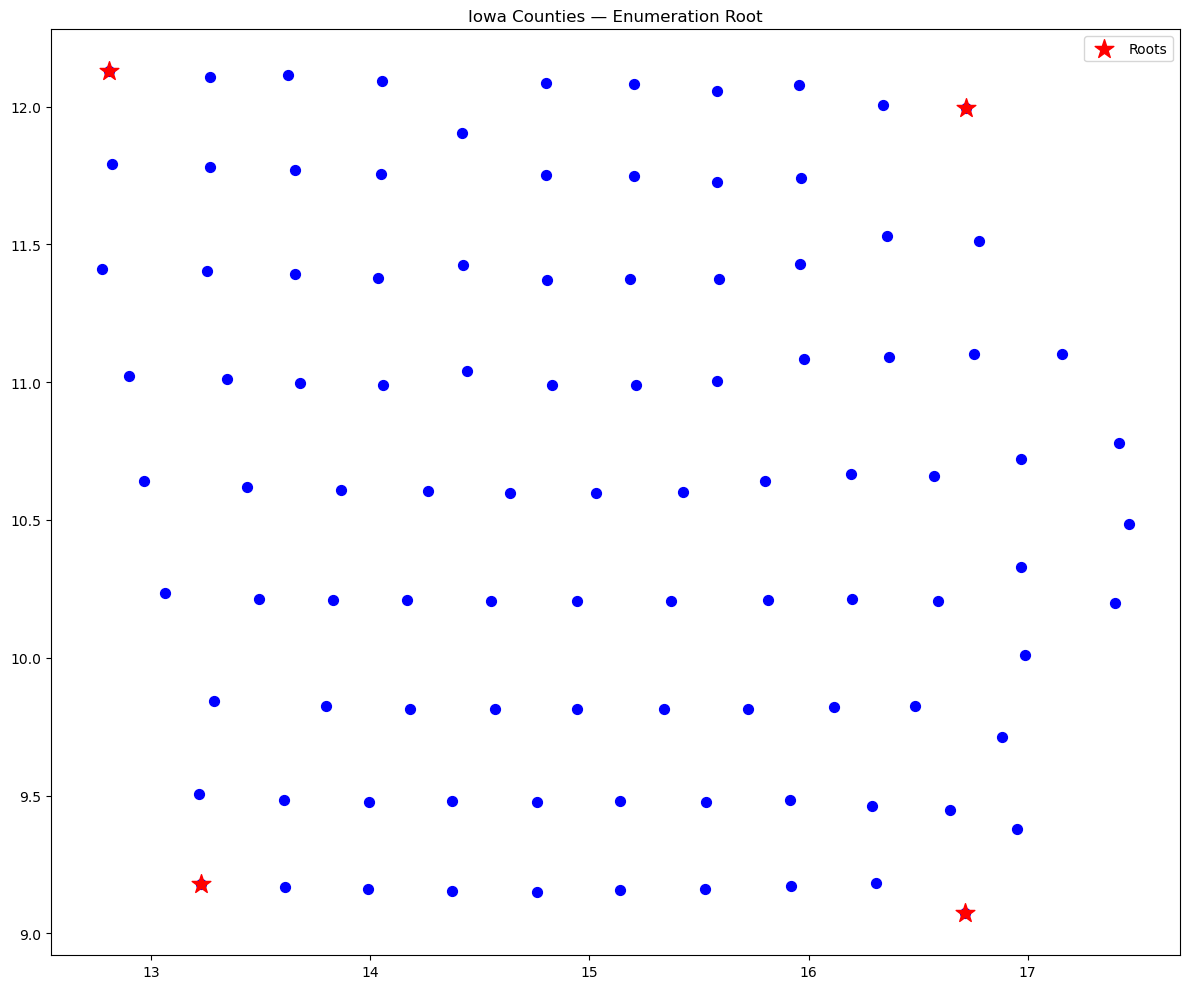

In [4]:
roots = get_roots(G_ia, k=4)
print(f"Root node: {roots}")

fig = visualize_roots(G_ia, roots, title="Iowa Counties \u2014 Enumeration Root")
plt.show()

In [5]:
DEVIATIONS = [0, 10, 20, 30, 40, 50]
CONTIGUITY = ["tree", "dist", "dag"]
POOL_SIZE = 1000000
TIME_LIMIT = 3600
K = 4

print(f"Deviations : {DEVIATIONS}")
print(f"Contiguity : {CONTIGUITY}")
print(f"Total runs : {len(DEVIATIONS) * len(CONTIGUITY)}")

Deviations : [0, 10, 20, 30, 40, 50]
Contiguity : ['tree', 'dist', 'dag']
Total runs : 18


In [6]:
df = run_enumeration_experiment(
    G_base=G_ia,
    deviations=DEVIATIONS,
    contiguity_models=CONTIGUITY,
    root=roots,
    k=K,
    distance_metric="euclidean",
    pool_size=POOL_SIZE,
    time_limit=TIME_LIMIT,
    results_file="../../results/IA_county_enumeration.csv",
)

Root(s): [56, 26, 40, 27]
Distance metric: euclidean
Setting Euclidean edge weights...

Total experiments: 18
Results will be saved to: ../../results/IA_county_enumeration.csv

[1/18] deviation=0 | contiguity=tree | distance=euclidean
Using L, U, k = 797593 797592 4
Set parameter Username
Academic license - for non-commercial use only - expires 2027-04-02
Set parameter OutputFlag to value 1
Set parameter LogToConsole to value 1
Set parameter MIPGap to value 0
Set parameter PoolSearchMode to value 2
Set parameter PoolSolutions to value 1000000
Set parameter TimeLimit to value 3600
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: 13th Gen Intel(R) Core(TM) i9-13900K, instruction set [SSE2|AVX|AVX2]
Thread count: 24 physical cores, 32 logical processors, using up to 32 threads

Non-default parameters:
TimeLimit  3600
MIPGap  0
PoolSolutions  1000000
PoolSearchMode  2

Optimize a model with 499 rows, 396 columns and 1972 nonzeros (Min)
Model fi

In [7]:
df

,time_best,objective_type,objective,obj_bound,obj_gap,nonzeros,num_solutions,status,contiguity,sparsity,num_callbacks,num_lazy_cuts,bnb_nodes,roots,deviation,distance_metric
0,0.005,None,NaN,inf,NaN,1972,0,Infeasible,tree,99.002044,0,0,0.0,"[56, 26, 40, 27]",0,euclidean
1,0.000,None,NaN,inf,NaN,1972,0,Infeasible,dist,99.002044,0,0,0.0,"[56, 26, 40, 27]",0,euclidean
2,0.006,None,NaN,inf,NaN,2468,0,Infeasible,dag,98.751037,0,0,0.0,"[56, 26, 40, 27]",0,euclidean
3,0.255,None,NaN,inf,NaN,1972,0,Infeasible,tree,99.002044,0,0,4359.0,"[56, 26, 40, 27]",10,euclidean
4,0.287,None,NaN,inf,NaN,1972,0,Infeasible,dist,99.002044,0,0,4359.0,"[56, 26, 40, 27]",10,euclidean
5,3600.026,None,0.0,0.0,0.0,2468,138,Time Limit,dag,98.751037,0,0,143612154.0,"[56, 26, 40, 27]",10,euclidean
6,0.352,None,NaN,inf,NaN,1972,0,Infeasible,tree,99.002044,0,0,3196.0,"[56, 26, 40, 27]",20,euclidean
7,0.382,None,NaN,inf,NaN,1972,0,Infeasible,dist,99.002044,0,0,3196.0,"[56, 26, 40, 27]",20,euclidean
8,3600.049,None,0.0,0.0,0.0,2468,1110,Time Limit,dag,98.751037,0,0,121975694.0,"[56, 26, 40, 27]",20,euclidean
9,0.317,None,NaN,inf,NaN,1972,0,Infeasible,tree,99.002044,0,0,4403.0,"[56, 26, 40, 27]",30,euclidean
